#### Task 1: Prepare a complete data analysis report on the given data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
data=pd.read_excel("Flight_Fare.xlsx")

In [3]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
data.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
data.shape

(10683, 11)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [8]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [9]:
data.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

#### Data Cleaning

In [10]:
data.duplicated().sum()

np.int64(220)

In [11]:
data.drop_duplicates(inplace=True)
print("Dupliacte values :",data.duplicated().sum())
print("Shape after droping duplicated :",data.shape)

Dupliacte values : 0
Shape after droping duplicated : (10463, 11)


I found around 220 duplicate rows in the dataset. I removed them to avoid bias, improve data quality and model performance, reduce training time, and ensure the model learns from unique records.

In [12]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [13]:
data.dropna(inplace=True)
print("Null Values :",data.isnull().sum())
print("Shape after drping null values :", data.shape)

Null Values : Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64
Shape after drping null values : (10462, 11)


In [14]:
data['Additional_Info'] = data['Additional_Info'].replace({'No Info': 'No info'})
data['Additional_Info'].value_counts()

Additional_Info
No info                         8185
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

### EDA

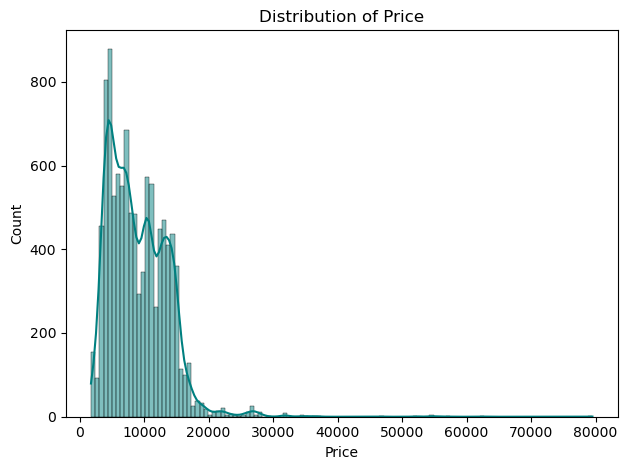

In [15]:
sns.histplot(x="Price",kde=True,data=data,color="teal")
plt.title('Distribution of Price')
plt.tight_layout()
plt.show()

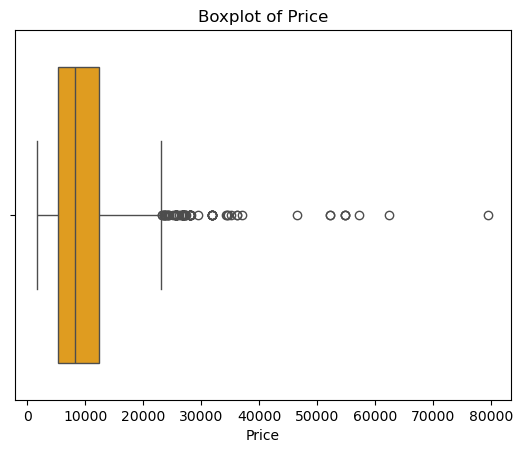

In [16]:
sns.boxplot(x="Price",data=data,color="orange")
plt.title("Boxplot of Price")
plt.show()

Your boxplot shows several high-price outliers. In a Flight Price Prediction dataset, these outliers may be real (for example, business class tickets, last-minute bookings, holiday travel), so you should not remove them automatically.

In [17]:
data.select_dtypes(include="object").columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info'],
      dtype='object')

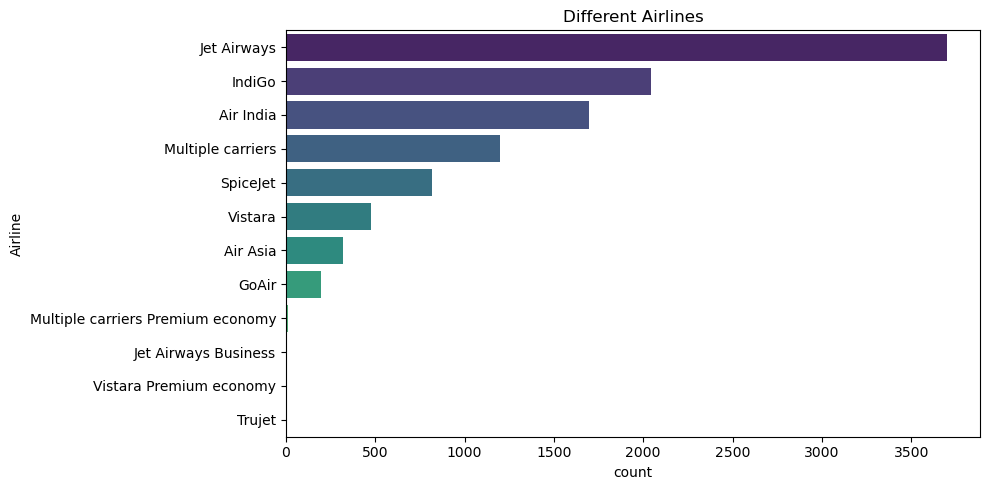

In [18]:
import warnings
warnings.filterwarnings('ignore')
order=data['Airline'].value_counts().index
figure=plt.figure(figsize=(10,5))
sns.countplot(y="Airline",order=order,data=data,palette="viridis")
plt.title("Different Airlines")
plt.tight_layout()
plt.show()

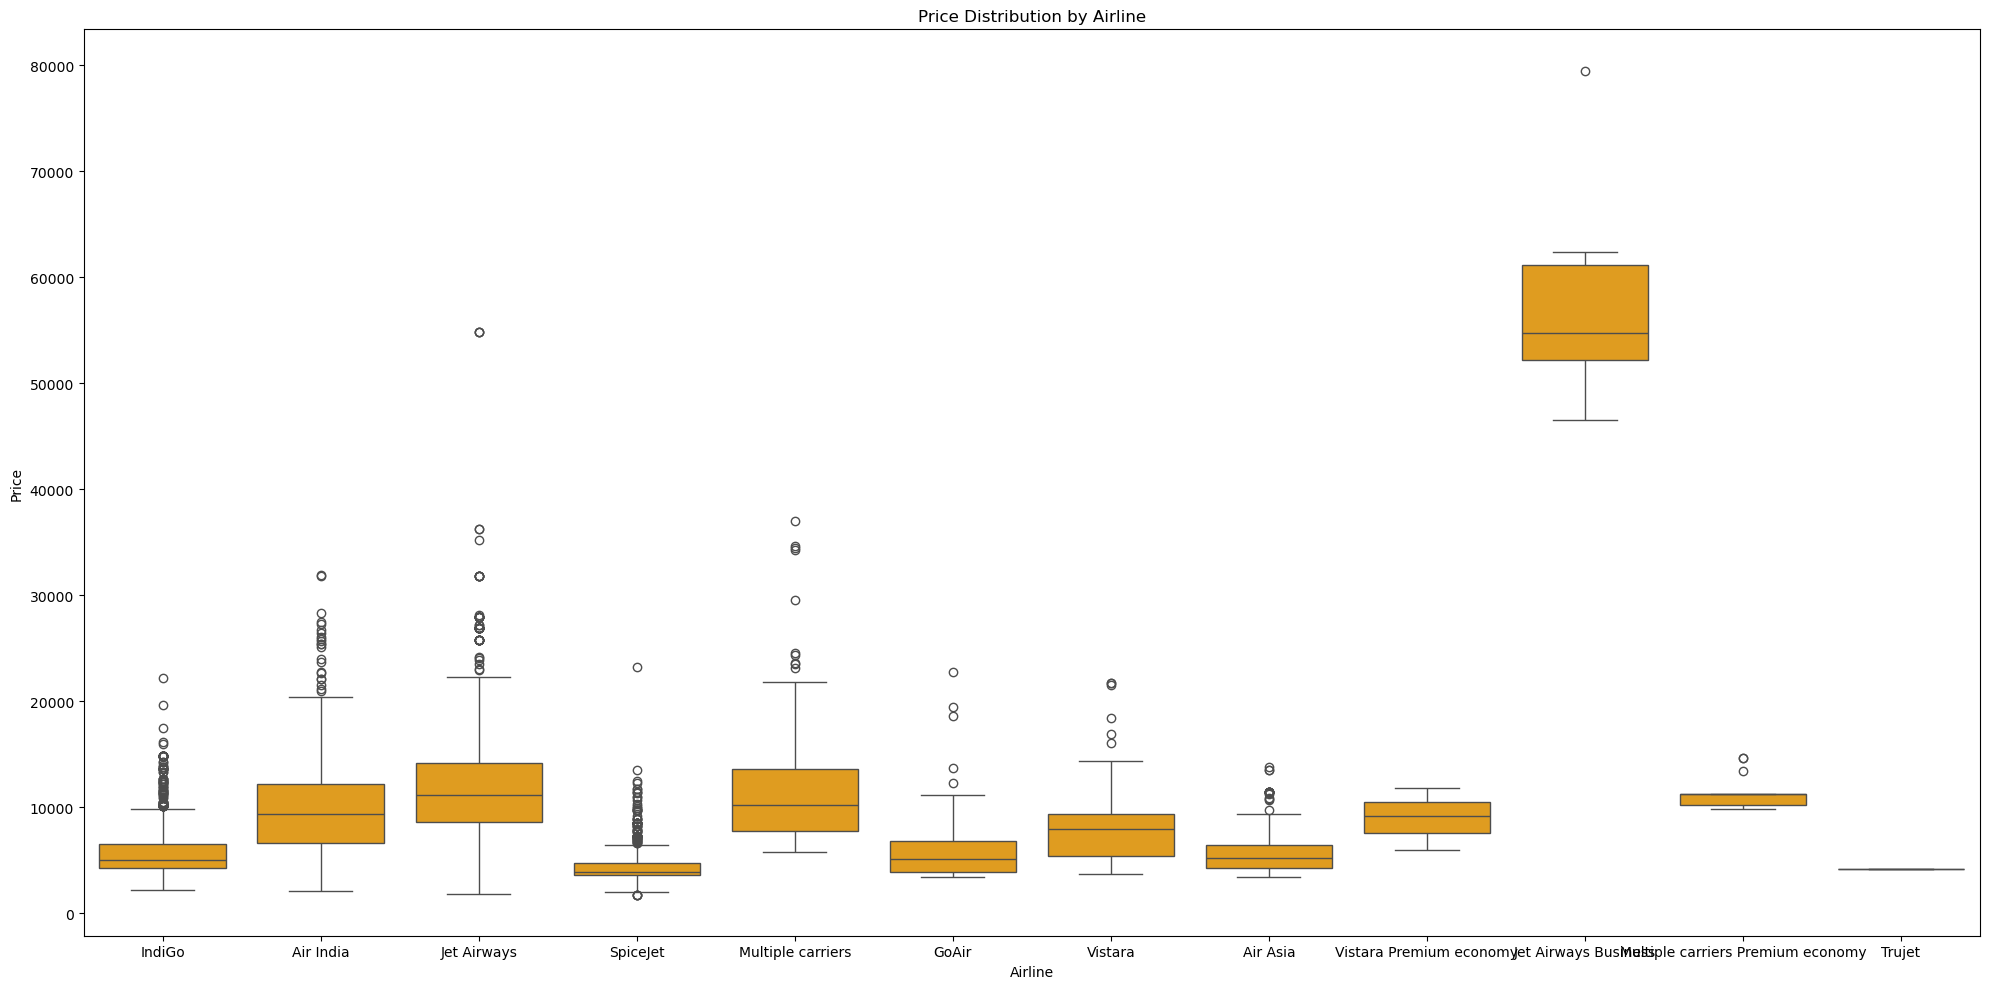

In [19]:
figure=plt.figure(figsize=(20,10))
sns.boxplot(x="Airline",y="Price",data=data,color="orange")
plt.title("Price Distribution by Airline")
plt.tight_layout()
plt.show()

I used a boxplot to compare ticket prices across different airlines. The boxplot shows the median price, the spread of prices (interquartile range), and any outliers. It helps identify which airlines generally have higher or lower ticket prices and how much the prices vary.

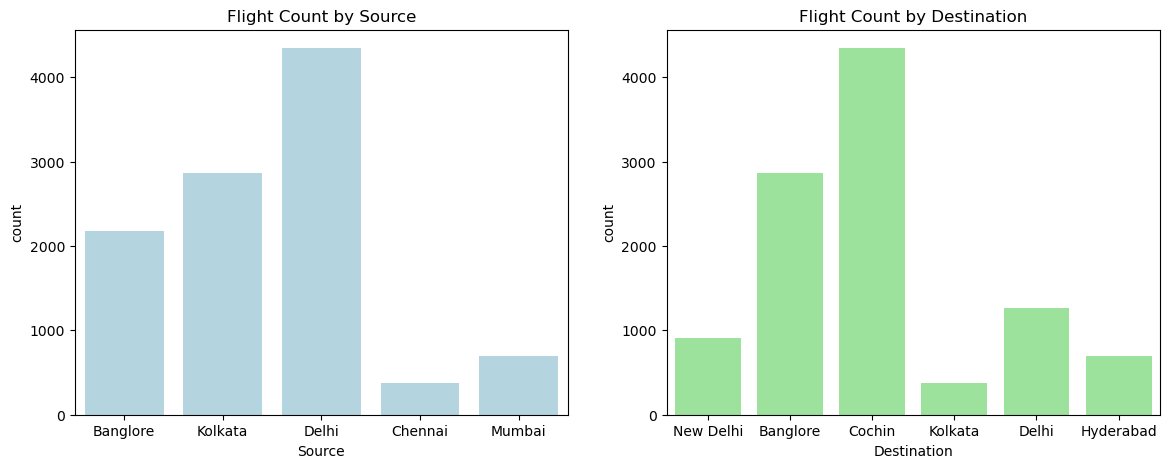

In [20]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.countplot(x='Source',ax=ax[0],color="lightblue",data=data)
ax[0].set_title("Flight Count by Source")
sns.countplot(x='Destination',ax=ax[1],color="lightgreen",data=data)
ax[1].set_title("Flight Count by Destination")
plt.show()

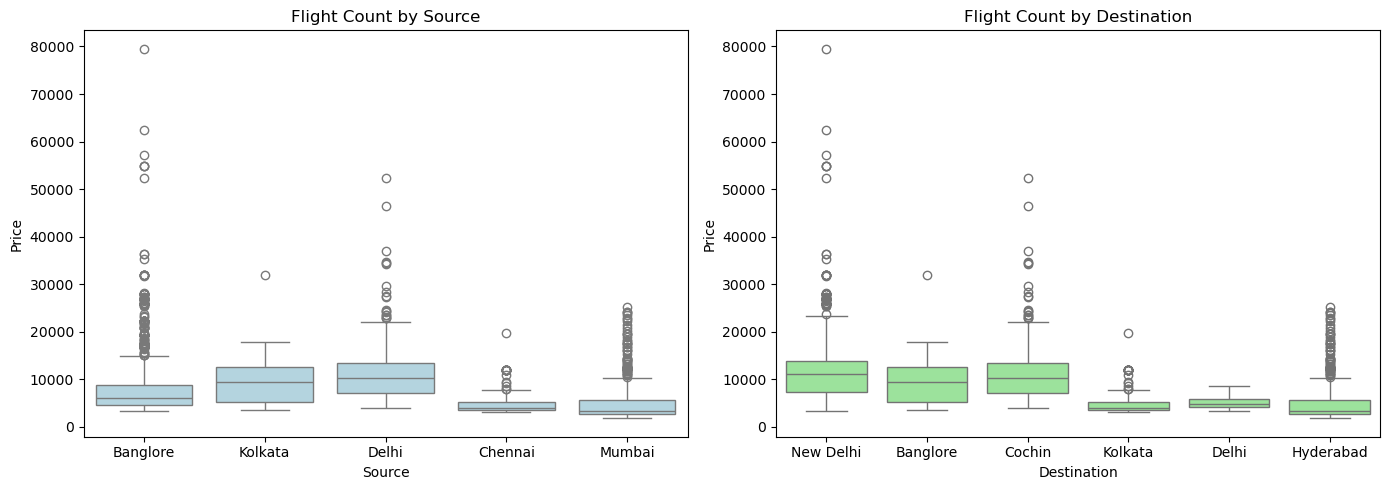

In [21]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.boxplot(x='Source',y="Price",ax=ax[0],color="lightblue",data=data)
ax[0].set_title("Flight Count by Source")
sns.boxplot(x='Destination',y="Price",ax=ax[1],color="lightgreen",data=data)
ax[1].set_title("Flight Count by Destination")
plt.tight_layout()
plt.show()

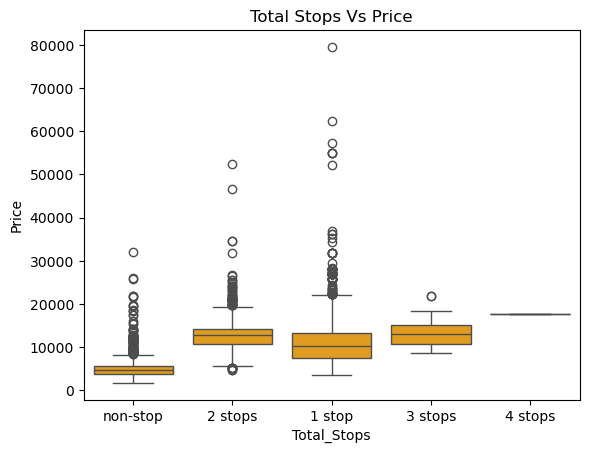

In [22]:
sns.boxplot(x='Total_Stops',y="Price",data=data,color="orange")
plt.title("Total Stops Vs Price")
plt.show()

#### Feature Engineering

In [23]:
from datetime import datetime

In [24]:
data.columns



Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [25]:
data['Date_of_Journey']=pd.to_datetime(data['Date_of_Journey'],format="%d/%m/%Y")
data['Journey_Day']=data['Date_of_Journey'].dt.day
data["Journey_month"]=data["Date_of_Journey"].dt.month
data["Journey_weekday"]=data["Date_of_Journey"].dt.dayofweek
data[["Date_of_Journey","Journey_Day","Journey_month","Journey_weekday"]].head()

,Date_of_Journey,Journey_Day,Journey_month,Journey_weekday
0,2019-03-24,24,3,6
1,2019-05-01,1,5,2
2,2019-06-09,9,6,6
3,2019-05-12,12,5,6
4,2019-03-01,1,3,4


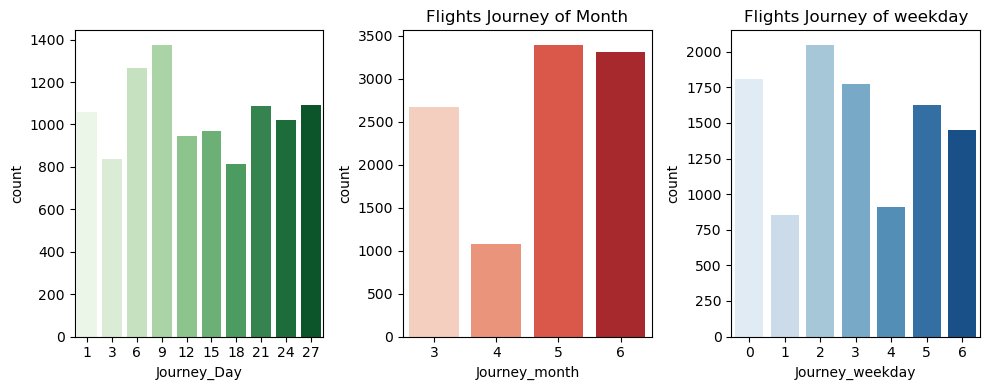

In [26]:
fig,ax=plt.subplots(1,3,figsize=(10,4))
sns.countplot(x="Journey_Day",data=data, ax=ax[0],palette="Greens")
ax[0].set_title=("Fights Journey of Day")
sns.countplot(x="Journey_month",data=data,ax=ax[1],palette="Reds")
ax[1].set_title("Flights Journey of Month")
sns.countplot(x="Journey_weekday",data=data,ax=ax[2],palette="Blues")
ax[2].set_title("Flights Journey of weekday")
plt.tight_layout()

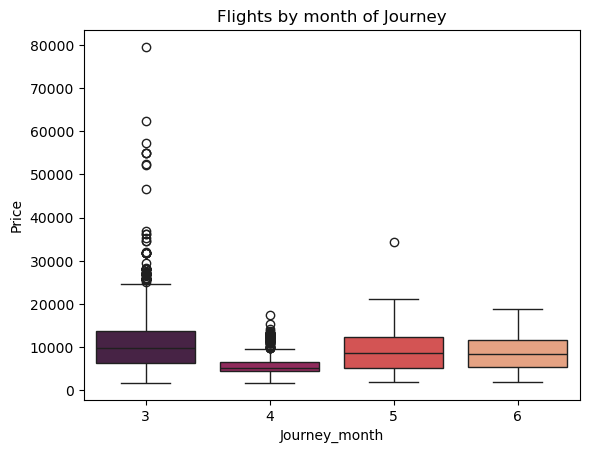

In [27]:
sns.boxplot(x="Journey_month",y="Price",data=data,palette="rocket")
plt.title("Flights by month of Journey")
plt.show()

In [28]:
data["Dep_Hour"]=pd.to_datetime(data["Dep_Time"]).dt.hour
data["Dep_minute"]=pd.to_datetime(data["Dep_Time"]).dt.minute
data["Arrival_Time_clean"]=data["Arrival_Time"].str.split(' ').str[0]
data["Arrival_Hour"]=pd.to_datetime(data["Arrival_Time"]).dt.hour
data["Arrival_minute"]=pd.to_datetime(data["Arrival_Time"]).dt.minute

In [29]:
data[["Dep_Time","Dep_Hour","Dep_minute","Arrival_Time","Arrival_Hour","Arrival_minute"]].head()

,Dep_Time,Dep_Hour,Dep_minute,Arrival_Time,Arrival_Hour,Arrival_minute
0,22:20,22,20,01:10 22 Mar,1,10
1,05:50,5,50,13:15,13,15
2,09:25,9,25,04:25 10 Jun,4,25
3,18:05,18,5,23:30,23,30
4,16:50,16,50,21:35,21,35


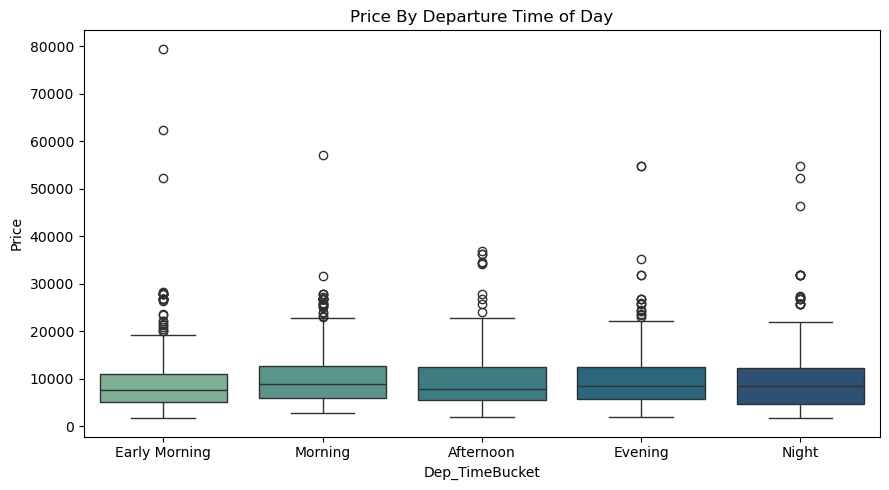

In [30]:
def time_bucket(hour):
    if 4<= hour<8 : return "Early Morning"
    elif 8<= hour<12 : return "Morning"
    elif 12<=hour<16 : return "Afternoon"
    elif 16<=hour<20 : return "Evening"
    elif 20<=hour<24 : return "Night"
    else : return  "Late Night" 
data["Dep_TimeBucket"]=data["Dep_Hour"].apply(time_bucket)

plt.figure(figsize=(9,5))
order=["Early Morning","Morning","Afternoon","Evening","Night"]
sns.boxplot(x="Dep_TimeBucket",y="Price",order=order,data=data,palette="crest")
plt.title("Price By Departure Time of Day")
plt.tight_layout()
plt.show()

In [31]:
stops_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
data['Total_Stops_Num'] = data['Total_Stops'].map(stops_map)
data['Total_Stops_Num'].value_counts()

Total_Stops_Num
1    5625
0    3475
2    1318
3      43
4       1
Name: count, dtype: int64

In [32]:
def duration_to_minutes(duration):
    duration = duration.strip()
    hours = 0
    minutes = 0
    if "h" in duration:
        hours = int(duration.split("h")[0].strip())
    if "m" in duration:
        minutes = int(duration.split("m")[0].split()[-1].strip())
    return hours * 60 + minutes

data["Duration_Minutes"] = data["Duration"].apply(duration_to_minutes)

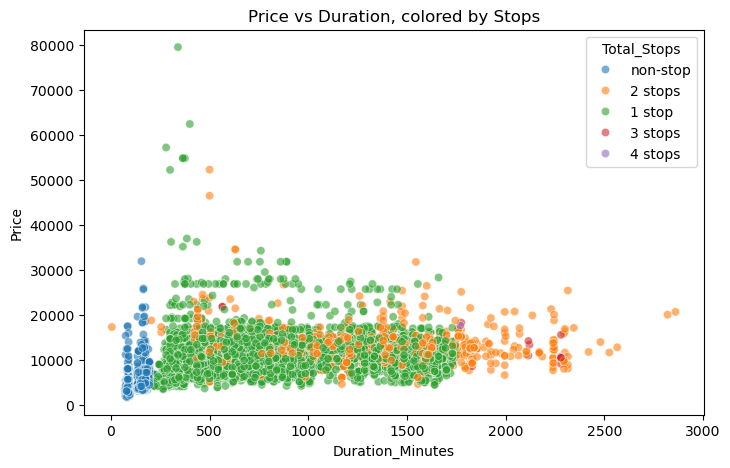

Correlation (Duration vs Price): 0.502


In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Duration_Minutes', y='Price', hue='Total_Stops', data=data, alpha=0.6)
plt.title('Price vs Duration, colored by Stops')
plt.show()
print("Correlation (Duration vs Price):", data['Duration_Minutes'].corr(data['Price']).round(3))

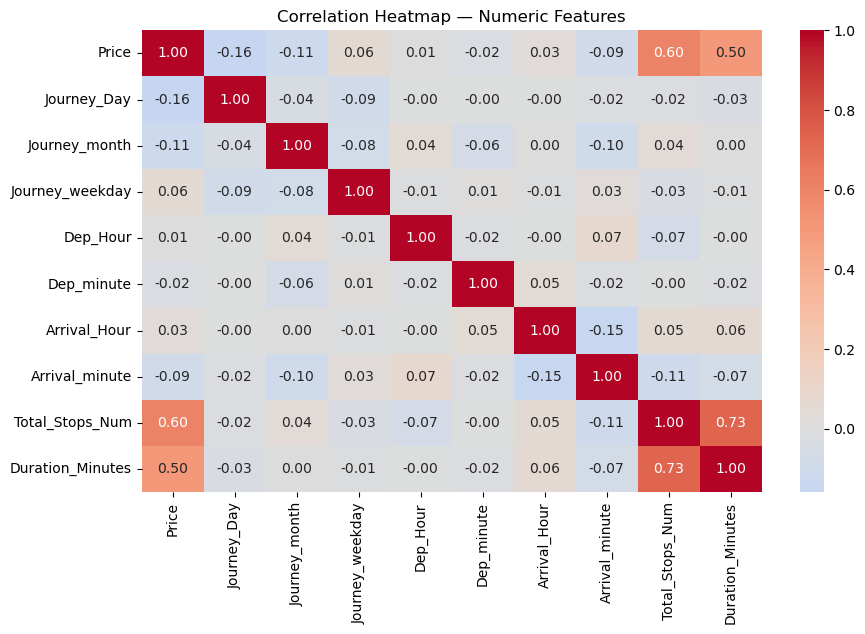

Total stops Number Vs Duration Minutes is the very strong Postive correlation 0.73
Journey Day Vs Price is the Weak Negative correlation 0.16


In [34]:
num_col = ["Price","Journey_Day", "Journey_month", "Journey_weekday",
           "Dep_Hour", "Dep_minute", "Arrival_Hour", "Arrival_minute",
           "Total_Stops_Num",'Duration_Minutes']
plt.figure(figsize=(10,6))
sns.heatmap(data[num_col].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features")
plt.show()
print("Total stops Number Vs Duration Minutes is the very strong Postive correlation 0.73")
print("Journey Day Vs Price is the Weak Negative correlation 0.16")

#### Data Analysis Report — Flight Price Prediction


#### Data Analysis Report — Flight Price Prediction

##### 1) Dataset Overview
###### Loaded the dataset and inspected it using `.head()`, `.tail()`, `.info()`, `.describe()`, `.columns`, and `.dtypes`. The dataset contains 10,683 rows and 11 columns, with 10 columns of type `object` (text) and only `Price` numeric initially — meaning nearly every feature required parsing before it could be used in modeling.

##### 2) Dataset Shape
###### Shape: (10683, 11). Price ranges from ₹1,759 to ₹79,512, with mean ₹9,087 and median ₹8,372 — the gap between mean and median already suggests right-skew, confirmed in the EDA.

##### 3) Duplicate Values
###### Found 220 duplicate rows and removed them using `drop_duplicates()`, reducing the dataset to (10463, 11). Removed to avoid bias, improve data quality and model performance, reduce training time, and ensure the model learns from unique records only.

##### 4) Missing Values
###### Found 1 missing value each in `Route` and `Total_Stops`, on the same single row (0.01% of the data). Dropped using `dropna()` rather than imputed, following the standard rule of removing rows when missing data is under ~5%. Final shape after cleaning: (10462, 11).

##### 5) Data Quality Fix
###### `Additional_Info` contained "No Info" and "No info" as separate categories due to inconsistent capitalization. Merged these into a single category ("No info"), which now accounts for the majority of the data (8,185 of 10,462 rows).

##### 6) Exploratory Data Analysis
###### **Price Distribution**: Right-skewed, most fares between ₹5,000–₹15,000 with a long tail to ₹79,512. High-value outliers were not removed, as they represent genuine premium/long-haul fares rather than data errors.
###### **Airline vs Price**: Boxplot shows premium carriers (Jet Airways Business, Multiple Carriers Premium Economy) command the highest fares; budget carriers cluster lower — Airline is a strong price driver.
###### **Source & Destination vs Price**: Countplots and boxplots show flight volume and price both vary meaningfully by departure/arrival city.
###### **Total_Stops vs Price**: Clear upward trend — more stops generally means a higher fare.
###### **Duration vs Price**: Scatterplot (colored by Total_Stops) shows longer flight durations generally align with more stops and higher prices, though with meaningful spread.

##### 7) Feature Engineering
###### `Date_of_Journey` split into `Journey_Day`, `Journey_month`, `Journey_weekday`.
###### `Dep_Time`/`Arrival_Time` split into `Dep_Hour`/`Dep_minute` and `Arrival_Hour`/`Arrival_minute` — `Arrival_Time` required stripping a trailing date for overnight flights before parsing.
###### `Total_Stops` mapped to ordinal numeric `Total_Stops_Num` (0–4), preserving natural order rather than using Label Encoding.
###### `Duration` (text like "2h 50m") converted to `Duration_Minutes` using a custom parser function.

##### 8) Correlation Analysis (corrected)
###### **`Total_Stops_Num` shows the strongest correlation with Price (≈ 0.60)**, followed by **`Duration_Minutes` (≈ 0.50)** — both moderately strong positive relationships, consistent with more stops and longer flights costing more.
###### **`Total_Stops_Num` and `Duration_Minutes` are themselves strongly correlated with each other (≈ 0.73)** — makes sense, since flights with more stops naturally take longer overall.
###### **`Journey_Day` shows only a weak negative correlation with Price (≈ -0.16)**, not a strong one. All other time-based features (`Dep_Hour`, `Arrival_Hour`, `Journey_month`, etc.) show weak correlations (under 0.12), suggesting Price is driven far more by route/stop factors than by time-of-day booking patterns.

In [35]:
data.drop(columns=['Date_of_Journey', 'Dep_Time', 'Arrival_Time', 'Arrival_Time_clean',
                    'Duration', 'Total_Stops', 'Route', 'Dep_TimeBucket'], inplace=True)

In [36]:
print(data.columns.tolist())

['Airline', 'Source', 'Destination', 'Additional_Info', 'Price', 'Journey_Day', 'Journey_month', 'Journey_weekday', 'Dep_Hour', 'Dep_minute', 'Arrival_Hour', 'Arrival_minute', 'Total_Stops_Num', 'Duration_Minutes']


 These columns were dropped because their useful information had already been extracted into cleaner, numeric features earlier in the pipeline. Date_of_Journey, Dep_Time, and Arrival_Time are raw text/datetime strings that carry no direct numeric meaning for a model — their relevant components (day, month, hour, minute) were already pulled out into Journey_Day, Journey_month, Dep_Hour, Dep_minute, Arrival_Hour, and Arrival_minute. Arrival_Time_clean was only an intermediate helper column used to strip the trailing date from overnight arrivals, and is no longer needed once Arrival_Hour/Arrival_minute are extracted. Duration was replaced by its numeric equivalent, Duration_Minutes. Total_Stops was replaced by its ordinal numeric version, Total_Stops_Num, which preserves the natural order (non-stop < 1 stop < 2 stops, etc.) that a raw text column can't. Route was dropped because it's largely redundant with Source, Destination, and Total_Stops, and its high cardinality (100+ unique paths) would add unnecessary dimensionality if kept. Finally, Dep_TimeBucket was dropped because it's just a re-bucketed, less granular version of Dep_Hour, which is already available as a raw numeric feature — keeping both would be redundant.

#### Task 2:

#### One-Hot Encoding
convert the one hot columns "Airline","Source","Destination","Additional_Info" because there in Nominal

In [37]:
data["Destination"]=data["Destination"].replace({"New Delhi":"Delhi"})

In [38]:
data=pd.get_dummies(data,columns=["Airline","Source","Destination","Additional_Info"],drop_first=True)

In [39]:
data.columns

Index(['Price', 'Journey_Day', 'Journey_month', 'Journey_weekday', 'Dep_Hour',
       'Dep_minute', 'Arrival_Hour', 'Arrival_minute', 'Total_Stops_Num',
       'Duration_Minutes', 'Airline_Air India', 'Airline_GoAir',
       'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Additional_Info_1 Short layover',
       'Additional_Info_2 Long layover', 'Additional_Info_Business class',
       'Additional_Info_Change airports',
       'Additional_Info_In-flight meal not included',
       'Additional_Info_No check-in baggage included',
       'Additional_Info_No info', 'Additional_Info_Red-eye flight'],
    

In [40]:
X=data.drop("Price",axis=1)

In [41]:
X.head()

,Journey_Day,Journey_month,Journey_weekday,Dep_Hour,Dep_minute,Arrival_Hour,Arrival_minute,Total_Stops_Num,Duration_Minutes,Airline_Air India,...,Destination_Hyderabad,Destination_Kolkata,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,24,3,6,22,20,1,10,0,170,False,...,False,False,False,False,False,False,False,False,True,False
1,1,5,2,5,50,13,15,2,445,True,...,False,False,False,False,False,False,False,False,True,False
2,9,6,6,9,25,4,25,2,1140,False,...,False,False,False,False,False,False,False,False,True,False
3,12,5,6,18,5,23,30,1,325,False,...,False,False,False,False,False,False,False,False,True,False
4,1,3,4,16,50,21,35,1,285,False,...,False,False,False,False,False,False,False,False,True,False


In [42]:
y=data["Price"]

In [43]:
y.head()

0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [45]:
print(X_train.shape,X_test.shape)

(8369, 36) (2093, 36)


In [46]:
from sklearn.preprocessing import StandardScaler
SS=StandardScaler()
X_train_scaled=SS.fit_transform(X_train)
X_test_scaled=SS.transform(X_test)

#### models 

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,BaggingRegressor,GradientBoostingRegressor
from sklearn.metrics import *
import numpy as np
models = {
    "Linear Regression": (LinearRegression(), True),
    "KNeighbors Regression": (KNeighborsRegressor(), True),
    "Decision Tree Regression": (DecisionTreeRegressor(random_state=42), False),
    "Random Forest Regression": (RandomForestRegressor(random_state=42), False),
    "AdaBoost Regression": (AdaBoostRegressor(random_state=42), False),
    "Bagging Regression": (BaggingRegressor(random_state=42), False),
    "Gradient Boosting Regression": (GradientBoostingRegressor(random_state=42), False)
}

In [48]:
results=[]
for name ,(model,needs_scaling) in models.items():
    Xtr=X_train_scaled if needs_scaling else X_train
    Xte=X_test_scaled if needs_scaling else X_test
    model.fit(Xtr,y_train)
    y_pred=model.predict(Xte)
    MAE=mean_absolute_error(y_test,y_pred)
    MSE=mean_squared_error(y_test,y_pred)
    RMSE=root_mean_squared_error(y_test,y_pred)
    r2_sco=r2_score(y_test,y_pred)
    results.append({
        "Model":name,
        "MAE":MAE,
        "MSE":MSE,
        "RMSE":RMSE,
        "R2_score":r2_sco
        
    }    
    )
    
    print(f"{name:30s} | MAE: {MAE:.2f} | MSE: {MSE:.2f} | RMSE : {RMSE:.2f} | R2_score : {r2_sco:.4f}")


Linear Regression              | MAE: 1781.50 | MSE: 7238655.17 | RMSE : 2690.47 | R2_score : 0.6528
KNeighbors Regression          | MAE: 1067.41 | MSE: 3993316.59 | RMSE : 1998.33 | R2_score : 0.8085
Decision Tree Regression       | MAE: 785.53 | MSE: 3933293.69 | RMSE : 1983.25 | R2_score : 0.8114
Random Forest Regression       | MAE: 670.59 | MSE: 2359924.29 | RMSE : 1536.20 | R2_score : 0.8868
AdaBoost Regression            | MAE: 2871.33 | MSE: 12743818.63 | RMSE : 3569.85 | R2_score : 0.3888
Bagging Regression             | MAE: 721.38 | MSE: 2569796.29 | RMSE : 1603.06 | R2_score : 0.8768
Gradient Boosting Regression   | MAE: 1261.86 | MSE: 4135509.79 | RMSE : 2033.60 | R2_score : 0.8017


In [49]:
result_data=pd.DataFrame(results)
result_data = result_data.sort_values("R2_score", ascending=False).reset_index(drop=True)
result_data

,Model,MAE,MSE,RMSE,R2_score
0,Random Forest Regression,670.586657,2.359924e+06,1536.204508,0.886816
1,Bagging Regression,721.379353,2.569796e+06,1603.058417,0.876750
2,Decision Tree Regression,785.529224,3.933294e+06,1983.253310,0.811355
3,KNeighbors Regression,1067.410989,3.993317e+06,1998.328448,0.808477
4,Gradient Boosting Regression,1261.862882,4.135510e+06,2033.595286,0.801657
5,Linear Regression,1781.495477,7.238655e+06,2690.474898,0.652827
6,AdaBoost Regression,2871.326816,1.274382e+07,3569.848544,0.388794


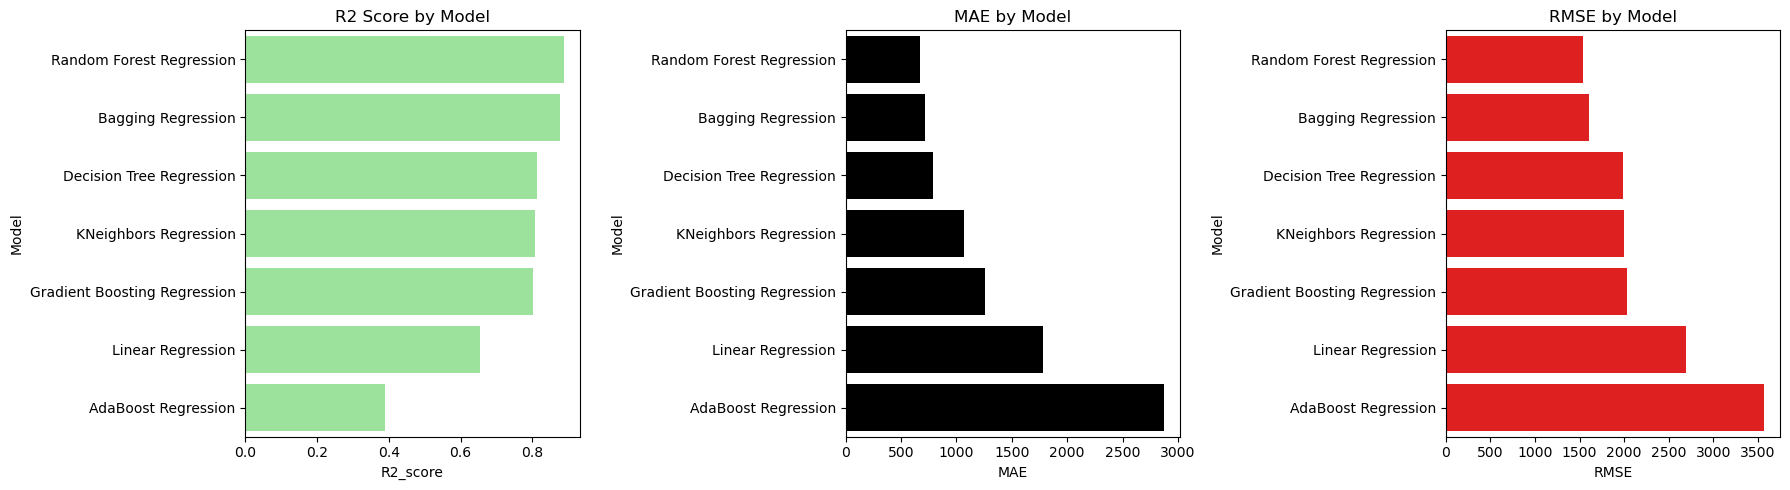

In [50]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x="R2_score", y="Model", data=result_data, color="lightgreen", ax=ax[0])
ax[0].set_title("R2 Score by Model")
sns.barplot(x="MAE", y="Model", data=result_data, color="black", ax=ax[1])
ax[1].set_title("MAE by Model")
sns.barplot(x="RMSE", y="Model", data=result_data, color="red", ax=ax[2])
ax[2].set_title("RMSE by Model")
plt.tight_layout()
plt.show()

#### Top 3 Regression Models
1) Random Forest Regression achieved the highest R² Score (0.8868) and the lowest MAE (670.59) and RMSE (1536.20), indicating the best predictive performance among all the models.
2) Bagging Regression achieved the second-highest R² Score (0.8768) with the second-lowest MAE (721.38) and RMSE (1603.06), making it the second-best performing model.
3) Decision Tree Regression achieved the third-highest R² Score (0.8114) with an MAE of 785.53 and an RMSE of 1983.25, ranking as the third-best model based on the evaluation metrics.

#### Hyper Tuning Techinque For Top 3 Regression Models

In [51]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
import numpy as np
rf_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=25, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 15, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,25
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [52]:
bag_params = {
    'n_estimators': [10, 20, 50, 100],
    'max_samples': [0.5, 0.7, 0.9, 1.0],
    'max_features': [0.5, 0.7, 0.9, 1.0],
    'bootstrap': [True, False]
}
bag_search = RandomizedSearchCV(
    BaggingRegressor(random_state=42),
    param_distributions=bag_params,
    n_iter=25, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
bag_search.fit(X_train, y_train)

,estimator,BaggingRegres...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_features': [0.5, 0.7, ...], 'max_samples': [0.5, 0.7, ...], 'n_estimators': [10, 20, ...]}"
,n_iter,25
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [53]:
dt_params = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}
dt_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=dt_params,
    n_iter=25, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
dt_search.fit(X_train, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,n_iter,25
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [54]:
tuned_models={
    "Bagging (Tuned)" : bag_search.best_estimator_,
    "Random Forest (Tuned)": rf_search.best_estimator_,
    "Decision Tree (Tuned)": dt_search.best_estimator_
}
tuned_results=[]
for name , model in tuned_models.items():
    y_tuned_pred=model.predict(X_test)
    mae=mean_absolute_error(y_test,y_tuned_pred)
    mse=mean_squared_error(y_test,y_tuned_pred)
    rmse=root_mean_squared_error(y_test,y_tuned_pred)
    r2=r2_score(y_test,y_tuned_pred)
    tuned_results.append(
        {
            "Model":name,"MAE":mae,"MSE":mse,"RMSE":rmse,"r2_score":r2
        }
    )
    print(f"{name:25s} | MAE : {mae:.2f}| MSE : {mse:.2f} | RMSE : {rmse:.2f} | r2_score {r2:.4f}")

print("-"*100)    
print("\nBest parsams per model :")
print(f"Bagging : {bag_search.best_params_}")
print("-"*130) 
print(f"Random Forest :{rf_search.best_params_}")
print("-"*130) 
print(f"Decision Tree : {dt_search.best_params_}")

Bagging (Tuned)           | MAE : 735.24| MSE : 2224642.48 | RMSE : 1491.52 | r2_score 0.8933
Random Forest (Tuned)     | MAE : 817.87| MSE : 2581532.46 | RMSE : 1606.71 | r2_score 0.8762
Decision Tree (Tuned)     | MAE : 814.81| MSE : 2935396.92 | RMSE : 1713.30 | r2_score 0.8592
----------------------------------------------------------------------------------------------------

Best parsams per model :
Bagging : {'n_estimators': 50, 'max_samples': 1.0, 'max_features': 0.7, 'bootstrap': False}
----------------------------------------------------------------------------------------------------------------------------------
Random Forest :{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
----------------------------------------------------------------------------------------------------------------------------------
Decision Tree : {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 25}


#### Feature Importance

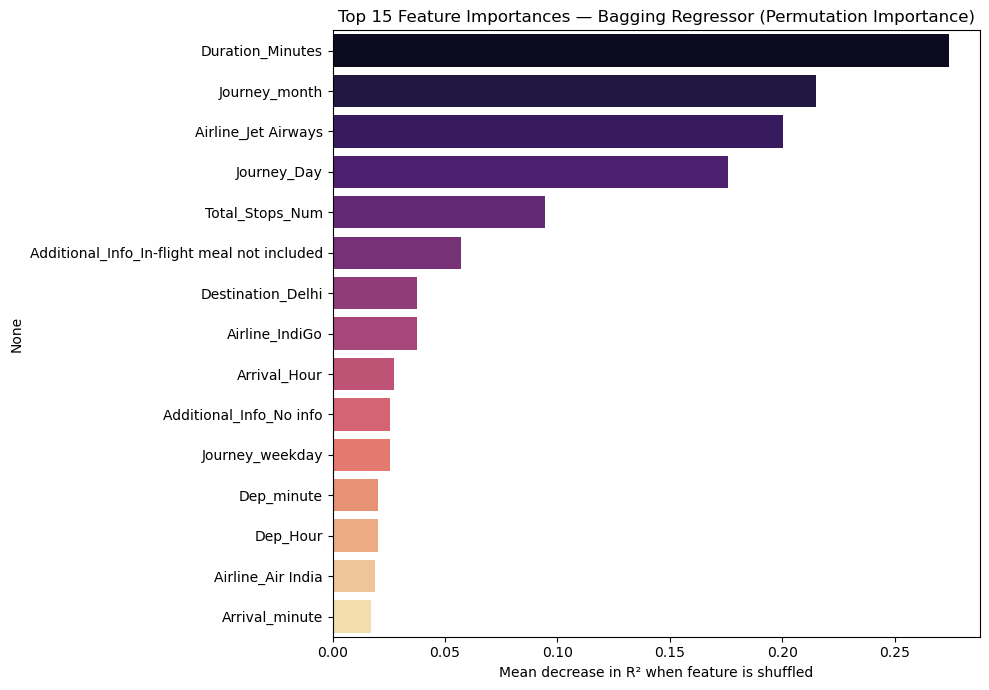

In [55]:
from sklearn.inspection import permutation_importance
best_bagging = tuned_models["Bagging (Tuned)"]

perm_result = permutation_importance(
    best_bagging, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1, scoring='r2'
)

perm_importance = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=perm_importance.values, y=perm_importance.index, palette='magma')
plt.title('Top 15 Feature Importances — Bagging Regressor (Permutation Importance)')
plt.xlabel('Mean decrease in R² when feature is shuffled')
plt.tight_layout()
plt.show()

#### Model Comparison Report

#### Baseline Model

In [56]:
result_data

,Model,MAE,MSE,RMSE,R2_score
0,Random Forest Regression,670.586657,2.359924e+06,1536.204508,0.886816
1,Bagging Regression,721.379353,2.569796e+06,1603.058417,0.876750
2,Decision Tree Regression,785.529224,3.933294e+06,1983.253310,0.811355
3,KNeighbors Regression,1067.410989,3.993317e+06,1998.328448,0.808477
4,Gradient Boosting Regression,1261.862882,4.135510e+06,2033.595286,0.801657
5,Linear Regression,1781.495477,7.238655e+06,2690.474898,0.652827
6,AdaBoost Regression,2871.326816,1.274382e+07,3569.848544,0.388794


#### Hyperplane model

In [57]:
result_model_final=pd.DataFrame(tuned_results)
print(result_model_final)

                   Model         MAE           MSE         RMSE  r2_score
0        Bagging (Tuned)  735.240040  2.224642e+06  1491.523544  0.893304
1  Random Forest (Tuned)  817.871434  2.581532e+06  1606.714804  0.876187
2  Decision Tree (Tuned)  814.809400  2.935397e+06  1713.300008  0.859215


##### Baseline stage: Random Forest led (R² 0.887), followed by Bagging (0.877) and Decision Tree (0.811) — all three tree-based ensembles clearly beat Linear Regression (R² 0.653) and KNN (0.809), confirming price depends on non-linear feature interactions a linear model can't capture.

##### After tuning (RandomizedSearchCV, 5-fold CV, 25 iterations each):

##### Bagging improved the most — R² rose from 0.877 → 0.893, MAE fell from 721 → 735 (roughly flat, within noise), and it became the top model overall.
##### Random Forest's R² actually dipped slightly (0.887 → 0.876) after tuning — a sign its default settings were already close to optimal for this feature set, and the tuned search traded a little variance for bias.
##### Decision Tree improved substantially (0.811 → 0.859) since a single tree benefits the most from constraining depth/splits to reduce overfitting, though it still trails the ensembles.

#### Visualization of the R2_score and MAE of Tuned model

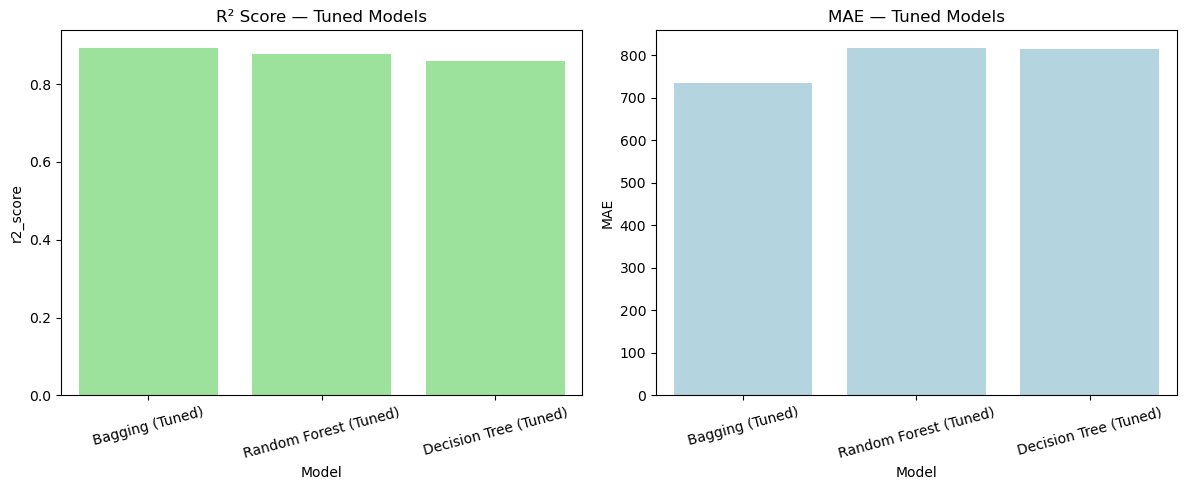

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x="Model", y="r2_score", data=result_model_final, color="lightgreen", ax=ax[0])
ax[0].set_title("R² Score — Tuned Models")
ax[0].tick_params(axis='x', rotation=15)
sns.barplot(x="Model", y="MAE", data=result_model_final, color="lightblue", ax=ax[1])
ax[1].set_title("MAE — Tuned Models")
ax[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

#### Report on Challenges faced

#### 1.Inconsistent Date and Time Formats

##### Challenge: The Arrival_Time column contained inconsistent formats. For overnight flights, the arrival date was embedded with the time (e.g., "01:10 22 Mar"), making direct time extraction difficult.

##### Technique Used: Separated the arrival date from the time and created a cleaned Arrival_Time column before extracting Arrival_Hour and Arrival_Minute.

##### Reason: This ensured consistent feature extraction and prevented incorrect parsing of mixed date-time formats.

#### 2. Converting Duration into a Numerical Feature

##### Challenge: The Duration column contained mixed formats such as "2h 50m", "19h", and "5m".

##### Technique Used: Developed a custom parser to extract hours and minutes independently, converted them into total minutes, and created a new feature Duration_Minutes.

##### Reason: Machine learning models require numerical inputs, and a single duration feature simplifies learning.

#### 3. High Cardinality of the Route Feature

##### Challenge: The Route column contained more than 100 unique categories, which would significantly increase dimensionality after one-hot encoding.

##### Technique Used: Removed the Route feature after confirming that its information was already represented by Source, Destination, and Total_Stops.

##### Reason: This reduced model complexity while preserving predictive information.

#### 4. Inconsistent Categories in Additional_Info

##### Challenge: The Additional_Info column contained duplicate categories due to inconsistent capitalization (e.g., "No Info" and "No info").

##### Technique Used: Standardized category names before encoding.

Reason: This prevented unnecessary duplicate categories and improved data consistency.

#### 5. Presence of High-Value Flight Fares

##### Challenge: The target variable (Price) was right-skewed and contained genuine premium-fare outliers.

##### Technique Used: Retained these observations and used tree-based ensemble models instead of removing or transforming them.

##### Reason: Premium fares represent valid business cases, and tree-based models are robust to skewed target distributions.

#### 6. Duplicate and Missing Records

##### Challenge: The dataset contained duplicate records and a small number of missing values.

##### Technique Used: Removed duplicate rows and dropped the single record with missing categorical information.

##### Reason: Removing duplicates prevented bias from repeated observations, while dropping one incomplete record caused negligible data loss.

#### 7. Encoding the Total_Stops Feature

##### Challenge: Total_Stops has a natural order (Non-stop < 1 Stop < 2 Stops < 3 Stops).

##### Technique Used: Applied ordinal encoding by mapping stop categories to numerical values (0–4).

##### Reason: Preserving the natural ordering allows tree-based models to make more meaningful splits than one-hot encoding.

#### 8. Selecting the Best Prediction Model

##### Challenge: Flight prices exhibit complex, non-linear relationships between features.

##### Technique Used: Compared multiple regression models, including Decision Tree, Random Forest, and Bagging Regressor. Hyperparameters were optimized using RandomizedSearchCV.

##### Reason: Tree-based ensemble models captured non-linear relationships more effectively and achieved higher prediction accuracy than simpler regression models.

##### The primary challenges included handling inconsistent date and time formats, converting textual features into numerical representations, reducing high-cardinality categorical features, cleaning inconsistent categories, processing duplicate and missing records, and selecting the most suitable regression model. By applying appropriate preprocessing, feature engineering, encoding techniques, and hyperparameter tuning, the Bagging Regressor achieved the best performance and was selected as the final model for flight price prediction.

In [59]:
import joblib
final_model = tuned_models["Bagging (Tuned)"]
joblib.dump(final_model, "flight_price_model.pkl")
print("Final model saved as flight_price_model.pkl")

Final model saved as flight_price_model.pkl


In [60]:
loaded_model = joblib.load("flight_price_model.pkl")

sample = X_test.iloc[[0]]          
predicted_price = loaded_model.predict(sample)[0]
actual_price = y_test.iloc[0]

print(f"Predicted price: {predicted_price:.0f}")
print(f"Actual price:    {actual_price:.0f}")

Predicted price: 15517
Actual price:    17996
